In [1]:
import seaborn as sns
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker


In [2]:
df=pd.read_csv('D:/mariam main/GUC\project/new/Nike_Sales_Cleaned.csv')


In [3]:
df.head(8)

,Order_ID,Gender_Category,Product_Line,Product_Name,Units_Sold,MRP,Discount_Applied,Revenue,Order_Date,Sales_Channel,Region,Profit,clothing_sizes,Shoe_Size
0,2000,Kids,Training,SuperRep Go,1.0,9671.05,0.47,5125.66,2024/03/09,Online,Bangalore,770.45,M,NaN
1,2001,Women,Soccer,Tiempo Legend,3.0,4957.93,0.00,14873.79,2024/07/09,Retail,Hyderabad,112.53,M,NaN
2,2002,Women,Soccer,Premier III,4.0,5172.14,0.00,20688.56,NaN,Retail,Mumbai,3337.34,M,NaN
3,2003,Kids,Lifestyle,Blazer Mid,1.0,9673.57,0.00,9673.57,2024/04/10,Online,Pune,3376.85,L,NaN
4,2004,Kids,Running,React Infinity,1.0,7557.71,0.00,7557.71,2024/09/12,Retail,Delhi,187.89,XL,NaN
5,2005,Women,Training,Flex Trainer,1.0,7363.96,0.00,7363.96,NaN,Retail,Delhi,1415.98,M,NaN
6,2006,Men,Training,SuperRep Go,1.0,6819.78,0.00,6819.78,2025/04/06,Online,Bangalore,1802.09,M,NaN
7,2007,Kids,Training,SuperRep Go,1.0,9671.05,0.32,6576.31,NaN,Retail,Bangalore,2928.36,M,NaN


what Gender buys the most ?

In [4]:
gender_sales_summary=df.groupby('Gender_Category')['Units_Sold'].sum().reset_index()
print("-------aggreation sold by genders------")
print (gender_sales_summary)

-------aggreation sold by genders------
  Gender_Category  Units_Sold
0            Kids      5838.0
1             Men      5630.0
2           Women      5309.0


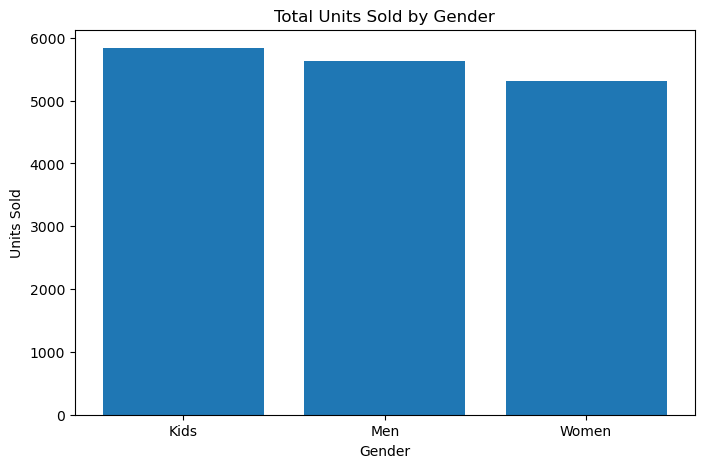

In [5]:
plt.figure(figsize=(8,5))
x_axis = gender_sales_summary['Gender_Category'].tolist()
y_axis = gender_sales_summary['Units_Sold'].tolist()
plt.bar(x_axis , y_axis)
plt.title("Total Units Sold by Gender")
plt.xlabel('Gender')
plt.ylabel('Units Sold')
plt.show()


what year sells the most 

In [6]:
df['years']=pd.to_datetime (df['Order_Date']).dt.year
df['month']=pd.to_datetime(df["Order_Date"]).dt.month

df

,Order_ID,Gender_Category,Product_Line,Product_Name,Units_Sold,MRP,Discount_Applied,Revenue,Order_Date,Sales_Channel,Region,Profit,clothing_sizes,Shoe_Size,years,month
0,2000,Kids,Training,SuperRep Go,1.0,9671.05,0.47,5125.66,2024/03/09,Online,Bangalore,770.45,M,NaN,2024.0,3.0
1,2001,Women,Soccer,Tiempo Legend,3.0,4957.93,0.00,14873.79,2024/07/09,Retail,Hyderabad,112.53,M,NaN,2024.0,7.0
2,2002,Women,Soccer,Premier III,4.0,5172.14,0.00,20688.56,NaN,Retail,Mumbai,3337.34,M,NaN,NaN,NaN
3,2003,Kids,Lifestyle,Blazer Mid,1.0,9673.57,0.00,9673.57,2024/04/10,Online,Pune,3376.85,L,NaN,2024.0,4.0
4,2004,Kids,Running,React Infinity,1.0,7557.71,0.00,7557.71,2024/09/12,Retail,Delhi,187.89,XL,NaN,2024.0,9.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2495,4495,Kids,Basketball,Kyrie Flytrap,3.0,6436.11,0.00,19308.33,2025/05/14,Online,Pune,2.97,XL,NaN,2025.0,5.0
2496,4496,Men,Basketball,Kyrie Flytrap,1.0,7561.85,0.00,7561.85,NaN,Online,Hyderabad,487.36,L,NaN,NaN,NaN
2497,4497,Men,Soccer,Tiempo Legend,1.0,6647.60,0.52,3190.85,2025/02/07,Retail,Bangalore,918.14,NaN,7.0,2025.0,2.0
2498,4498,Women,Training,ZoomX Invincible,4.0,5358.70,0.00,21434.80,2024/11/12,Online,Mumbai,3352.29,NaN,NaN,2024.0,11.0


In [7]:
yearly_Revenu = df.groupby('years')['Revenue'].sum().reset_index()
yearly_Revenu

,years,Revenue
0,2023.0,945382.00
1,2024.0,7255043.76
2,2025.0,7030265.88


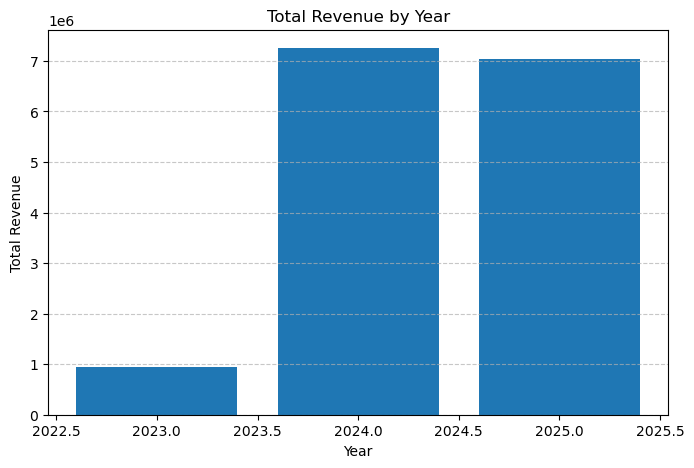

In [8]:
plt.figure(figsize=(8,5))
plt.bar(yearly_Revenu['years']  , yearly_Revenu ['Revenue'])
plt.title('Total Revenue by Year')
plt.xlabel('Year')
plt.ylabel('Total Revenue')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

how customer buys in each year 

In [9]:
channel_Sales =df.groupby('Sales_Channel')['years'].value_counts()
channel_Sales

Sales_Channel  years 
Online         2025.0    452
               2024.0    433
               2023.0     61
Retail         2024.0    459
               2025.0    422
               2023.0     57
Name: count, dtype: int64

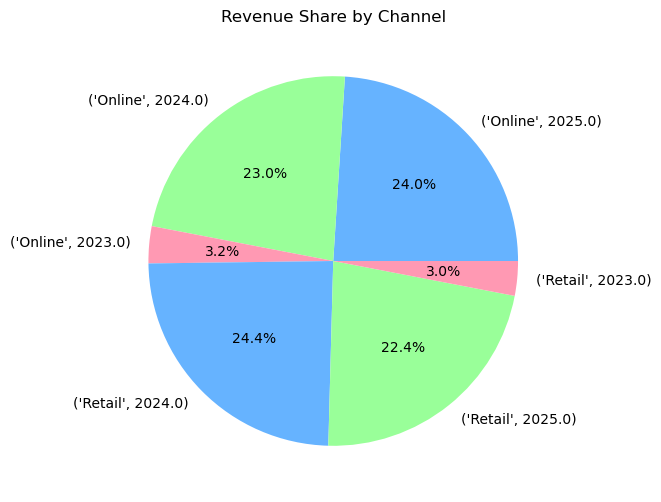

In [10]:


plt.figure(figsize=(6, 6))
plt.pie(channel_Sales, labels=channel_Sales.index, autopct='%1.1f%%', colors=['#66b3ff', '#99ff99' , "#ff99b3"])
plt.title('Revenue Share by Channel')
plt.show()

What region most sells 

In [11]:
region_sales = df.groupby('Region')['Revenue'].sum().sort_values(ascending=False)

print(region_sales)

Region
Mumbai       3566977.95
Delhi        3440407.84
Kolkata      3407515.33
Hyderabad    3365299.54
Pune         3274638.93
Bangalore    3218528.90
Name: Revenue, dtype: float64


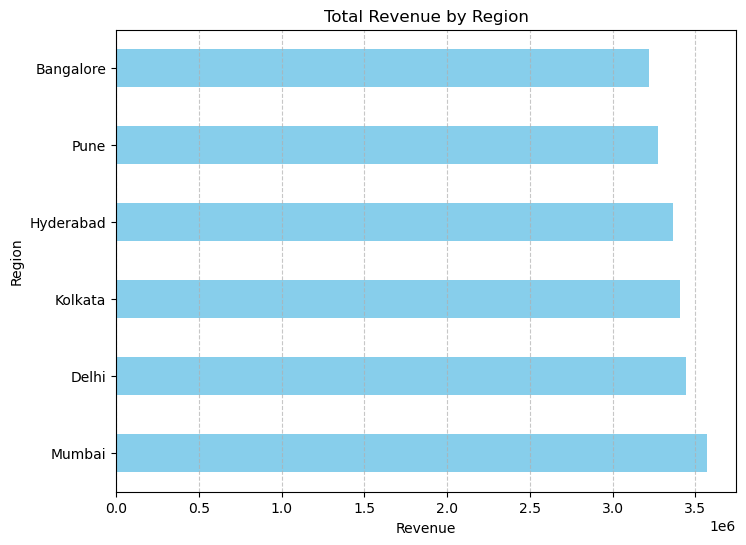

In [12]:


plt.figure(figsize=(8, 6))
region_sales.plot(kind='barh', color='skyblue')
plt.title('Total Revenue by Region')
plt.xlabel('Revenue')
plt.ylabel('Region')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

total profit in each year 

In [13]:
total_profit_yearly =df.groupby('years')['Profit'].sum().reset_index()
total_profit_yearly

,years,Profit
0,2023.0,207438.08
1,2024.0,1454979.06
2,2025.0,1415329.93


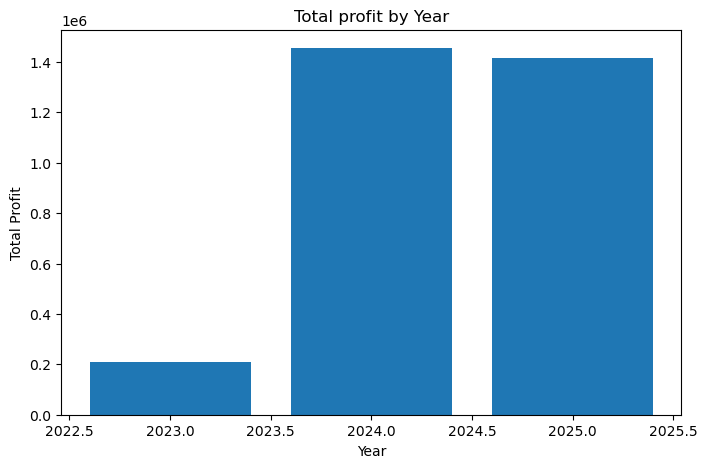

In [14]:
plt.figure(figsize=(8,5))
plt.bar(total_profit_yearly['years']  , total_profit_yearly ['Profit'])
plt.title('Total profit by Year')
plt.xlabel('Year')
plt.ylabel('Total Profit')
plt.show()

In [15]:
df

,Order_ID,Gender_Category,Product_Line,Product_Name,Units_Sold,MRP,Discount_Applied,Revenue,Order_Date,Sales_Channel,Region,Profit,clothing_sizes,Shoe_Size,years,month
0,2000,Kids,Training,SuperRep Go,1.0,9671.05,0.47,5125.66,2024/03/09,Online,Bangalore,770.45,M,NaN,2024.0,3.0
1,2001,Women,Soccer,Tiempo Legend,3.0,4957.93,0.00,14873.79,2024/07/09,Retail,Hyderabad,112.53,M,NaN,2024.0,7.0
2,2002,Women,Soccer,Premier III,4.0,5172.14,0.00,20688.56,NaN,Retail,Mumbai,3337.34,M,NaN,NaN,NaN
3,2003,Kids,Lifestyle,Blazer Mid,1.0,9673.57,0.00,9673.57,2024/04/10,Online,Pune,3376.85,L,NaN,2024.0,4.0
4,2004,Kids,Running,React Infinity,1.0,7557.71,0.00,7557.71,2024/09/12,Retail,Delhi,187.89,XL,NaN,2024.0,9.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2495,4495,Kids,Basketball,Kyrie Flytrap,3.0,6436.11,0.00,19308.33,2025/05/14,Online,Pune,2.97,XL,NaN,2025.0,5.0
2496,4496,Men,Basketball,Kyrie Flytrap,1.0,7561.85,0.00,7561.85,NaN,Online,Hyderabad,487.36,L,NaN,NaN,NaN
2497,4497,Men,Soccer,Tiempo Legend,1.0,6647.60,0.52,3190.85,2025/02/07,Retail,Bangalore,918.14,NaN,7.0,2025.0,2.0
2498,4498,Women,Training,ZoomX Invincible,4.0,5358.70,0.00,21434.80,2024/11/12,Online,Mumbai,3352.29,NaN,NaN,2024.0,11.0


In [16]:
df.to_csv('Nike_Sales_Cleaned.csv', index=False)

In [17]:
df

,Order_ID,Gender_Category,Product_Line,Product_Name,Units_Sold,MRP,Discount_Applied,Revenue,Order_Date,Sales_Channel,Region,Profit,clothing_sizes,Shoe_Size,years,month
0,2000,Kids,Training,SuperRep Go,1.0,9671.05,0.47,5125.66,2024/03/09,Online,Bangalore,770.45,M,NaN,2024.0,3.0
1,2001,Women,Soccer,Tiempo Legend,3.0,4957.93,0.00,14873.79,2024/07/09,Retail,Hyderabad,112.53,M,NaN,2024.0,7.0
2,2002,Women,Soccer,Premier III,4.0,5172.14,0.00,20688.56,NaN,Retail,Mumbai,3337.34,M,NaN,NaN,NaN
3,2003,Kids,Lifestyle,Blazer Mid,1.0,9673.57,0.00,9673.57,2024/04/10,Online,Pune,3376.85,L,NaN,2024.0,4.0
4,2004,Kids,Running,React Infinity,1.0,7557.71,0.00,7557.71,2024/09/12,Retail,Delhi,187.89,XL,NaN,2024.0,9.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2495,4495,Kids,Basketball,Kyrie Flytrap,3.0,6436.11,0.00,19308.33,2025/05/14,Online,Pune,2.97,XL,NaN,2025.0,5.0
2496,4496,Men,Basketball,Kyrie Flytrap,1.0,7561.85,0.00,7561.85,NaN,Online,Hyderabad,487.36,L,NaN,NaN,NaN
2497,4497,Men,Soccer,Tiempo Legend,1.0,6647.60,0.52,3190.85,2025/02/07,Retail,Bangalore,918.14,NaN,7.0,2025.0,2.0
2498,4498,Women,Training,ZoomX Invincible,4.0,5358.70,0.00,21434.80,2024/11/12,Online,Mumbai,3352.29,NaN,NaN,2024.0,11.0
